<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Testing the Installation

_Prepared by Claudia Zendejas-Morales_

This notebook runs a minimal functionality check for the main stack used in this tutorial:
- Qiskit
- Qiskit Machine Learning
- PennyLane


## 1) Qiskit quick test (GHZ circuit)

We build a 3-qubit GHZ circuit, draw it, and run a simple statevector simulation.

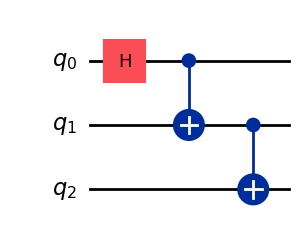

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)

qc.draw("mpl")

### Optional: LaTeX state rendering check (`pylatexenc`)

If `pylatexenc` is available, the GHZ state is displayed in LaTeX form. If not, this cell explains how to install it.

In [2]:
from importlib.util import find_spec

sv = Statevector.from_instruction(qc)

if find_spec("pylatexenc") is None:
    print("Optional dependency missing: pylatexenc")
    print("To enable LaTeX state rendering, run one of:")
    print("  %pip install pylatexenc")
    print("  %pip install 'qiskit[visualization]'")
else:
    display(sv.draw("latex"))

<IPython.core.display.Latex object>

Statevector probabilities:
{'000': 0.4999999999999999, '111': 0.4999999999999999}


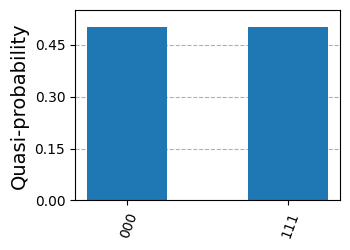

In [3]:
from qiskit.visualization import plot_histogram

sv = Statevector.from_instruction(qc)
probs = sv.probabilities_dict()
clean_probs = {str(k): float(v) for k, v in probs.items()}

print("Statevector probabilities:")
print(clean_probs)

fig = plot_histogram(clean_probs, figsize=(3.6, 2.6), bar_labels=False)
fig.tight_layout()
fig

## 2) Qiskit Machine Learning quick test

We build a simple quantum kernel, evaluate a kernel matrix, and visualize the feature map circuit.

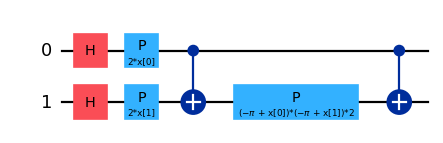

Kernel matrix shape: (3, 3)
[[1.         0.14705581 0.44776286]
 [0.14705581 1.         0.18458887]
 [0.44776286 0.18458887 1.        ]]


In [4]:
import numpy as np
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel

x_vec = np.array([
    [0.1, 0.2],
    [0.4, 0.3],
    [0.8, 0.7],
])

feature_map = zz_feature_map(feature_dimension=2, reps=1)
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)
kernel_matrix = quantum_kernel.evaluate(x_vec)

display(feature_map.draw("mpl", scale=0.8))

print("Kernel matrix shape:", kernel_matrix.shape)
print(kernel_matrix)

## 3) PennyLane quick test

We define and run a tiny PennyLane circuit, print a text diagram, and render a Matplotlib figure.

Output probabilities: [0.49811126 0.00188874 0.00188874 0.49811126]
0: ──H─╭●──RY(0.12)─┤ ╭Probs
1: ────╰X───────────┤ ╰Probs


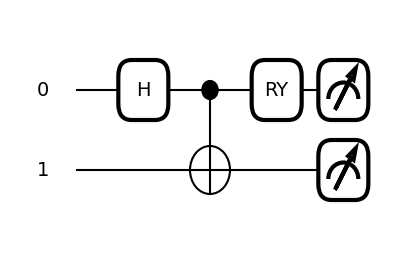

In [5]:
import pennylane as qml

dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def simple_circuit(theta):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.RY(theta, wires=0)
    return qml.probs(wires=[0, 1])

theta = 0.123
print("Output probabilities:", simple_circuit(theta))
print(qml.draw(simple_circuit)(theta))

fig, _ = qml.draw_mpl(simple_circuit)(theta)
fig.set_size_inches(4.0, 2.4)

<div style="background:#e8f7ec;color:#111111;border-left:6px solid #2f9e44;padding:12px 14px;border-radius:6px;">
<b>Installation check completed:</b> If all cells run without errors and you can see the circuit plots, your environment is ready for the QML tutorial.
</div>